In [ ]:
------------------------------------------------------------------------------------------
                                    TASK SUBMISSION                                 
------------------------------------------------------------------------------------------
                                                     
  Full Name : chenna Balaji Sri Manikanta           
  Intership Track : Data Analytics                   
  Task Title : Task 1 - EDA on Retail Sales Data    
  Dataset : https://www.kaggle.com/datasets/devbr22/retail-sales-dataset?resource=download   

-------------------------------------------------------------------------------------------

In [3]:
# Importing Python Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 

In [6]:
# Setting visual style
sns.set_style("whitegrid")

In [7]:
# Setting figure size and font size
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 12

In [4]:
# Load dataset and perform initial inspection
df = pd.read_csv("Retail_Sales.csv")

print("First 5 rows:")
display(df.head())

First 5 rows:


,transactions_id,sale_date,sale_time,customer_id,gender,age,category,quantiy,price_per_unit,cogs,total_sale
0,180,2022-11-05,10:47:00,117,Male,41.0,Clothing,3.0,300.0,129.0,900.0
1,522,2022-07-09,11:00:00,52,Male,46.0,Beauty,3.0,500.0,145.0,1500.0
2,559,2022-12-12,10:48:00,5,Female,40.0,Clothing,4.0,300.0,84.0,1200.0
3,1180,2022-01-06,08:53:00,85,Male,41.0,Clothing,3.0,300.0,129.0,900.0
4,1522,2022-11-14,08:35:00,48,Male,46.0,Beauty,3.0,500.0,235.0,1500.0


In [10]:
# Check number of rows and columns
df.shape

(2000, 11)

In [11]:
# Check data types of all columns
df.dtypes

transactions_id      int64
sale_date              str
sale_time              str
customer_id          int64
gender                 str
age                float64
category               str
quantiy            float64
price_per_unit     float64
cogs               float64
total_sale         float64
dtype: object

In [58]:
# Check missing values in each column
df.isnull().sum()

transactions_id     0
sale_date           0
sale_time           0
customer_id         0
gender              0
age                 0
category            0
quantiy             0
price_per_unit      0
cogs                0
total_sale          0
age_group          10
dtype: int64

In [56]:
df["age"] = df["age"].fillna(df["age"].median())
df["quantiy"] = df["quantiy"].fillna(df["quantiy"].median())
df["price_per_unit"] = df["price_per_unit"].fillna(df["price_per_unit"].median())
df["cogs"] = df["cogs"].fillna(df["cogs"].median())
df["total_sale"] = df["total_sale"].fillna(df["total_sale"].median())

In [57]:
# Detailed information about the dataset
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   transactions_id  2000 non-null   int64         
 1   sale_date        2000 non-null   datetime64[us]
 2   sale_time        2000 non-null   str           
 3   customer_id      2000 non-null   int64         
 4   gender           2000 non-null   str           
 5   age              2000 non-null   float64       
 6   category         2000 non-null   str           
 7   quantiy          2000 non-null   float64       
 8   price_per_unit   2000 non-null   float64       
 9   cogs             2000 non-null   float64       
 10  total_sale       2000 non-null   float64       
 11  age_group        1990 non-null   category      
dtypes: category(1), datetime64[us](1), float64(5), int64(2), str(3)
memory usage: 216.1 KB


In [5]:
# Descriptive Statistics
stats = pd.DataFrame({
    "Mean": df.mean(numeric_only=True),
    "Median": df.median(numeric_only=True),
    "Mode": df.mode(numeric_only=True).iloc[0],
    "Standard Deviation": df.std(numeric_only=True)
})

display(stats)

,Mean,Median,Mode,Standard Deviation
transactions_id,1000.500000,1000.5,1.0,577.494589
customer_id,66.341500,69.0,1.0,44.937185
age,41.343216,42.0,43.0,13.668167
quantiy,2.512769,3.0,4.0,1.132708
price_per_unit,180.117677,50.0,50.0,189.685225
cogs,95.023886,27.5,13.5,121.898695
total_sale,456.544817,150.0,50.0,560.101381


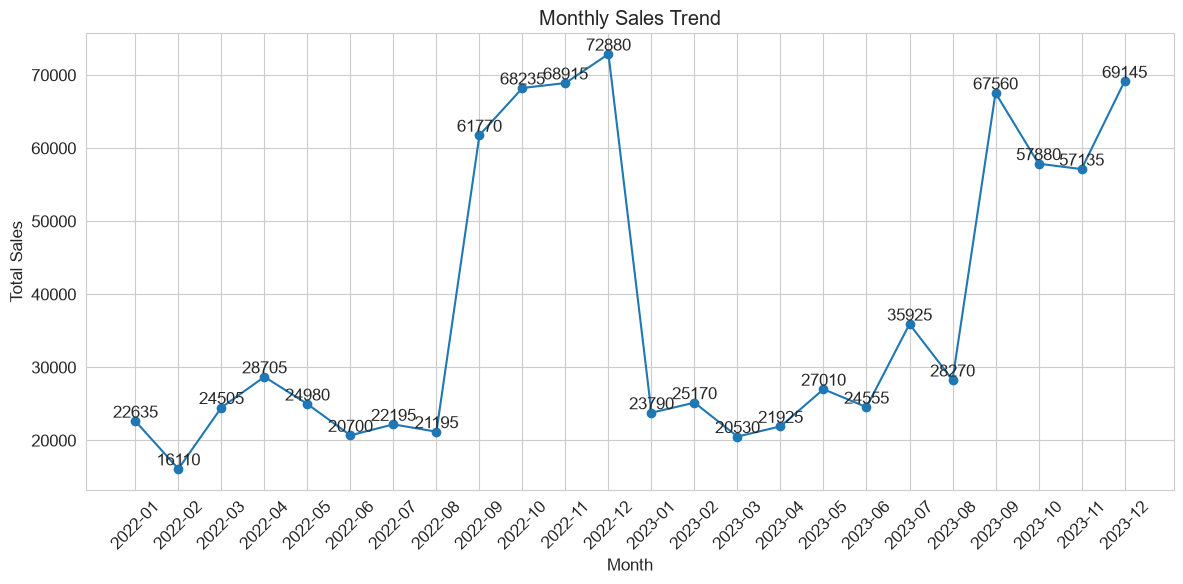

In [46]:
# Monthly Sales Trend
df["sale_date"] = pd.to_datetime(df["sale_date"])

monthly_sales = df.groupby(
    df["sale_date"].dt.to_period("M")
)["total_sale"].sum()

plt.figure(figsize=(12, 6))
plt.plot(monthly_sales.index.astype(str), monthly_sales.values, marker="o")

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)

for x, y in enumerate(monthly_sales.values):
    plt.text(x, y, f"{y:.0f}", ha="center", va="bottom")

plt.tight_layout()
plt.show()

Observation : 
Sales start increasing from August and continue to rise until December, followed by a sharp decline in January in both the years

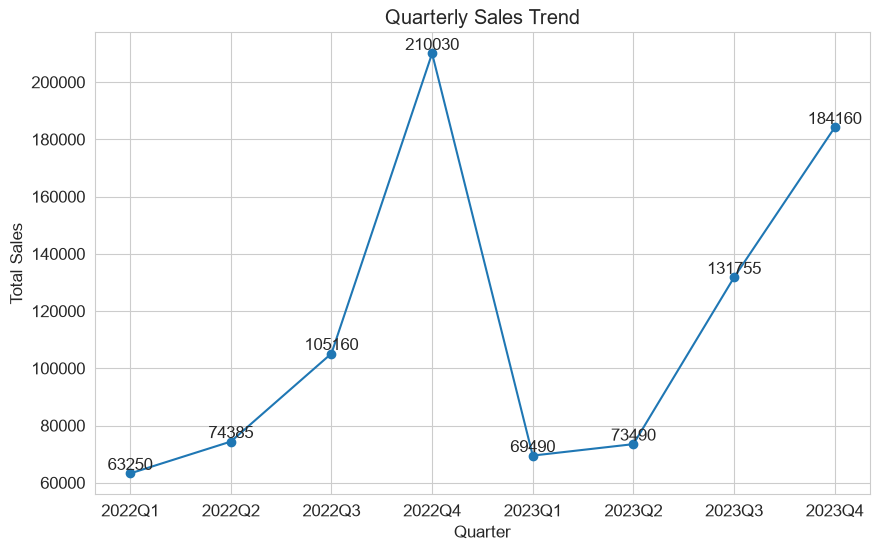

In [47]:
# Quarterly Sales Trend
quarterly_sales = df.groupby(
    df["sale_date"].dt.to_period("Q")
)["total_sale"].sum()

plt.figure(figsize=(10, 6))
plt.plot(quarterly_sales.index.astype(str), quarterly_sales.values, marker="o")

plt.title("Quarterly Sales Trend")
plt.xlabel("Quarter")
plt.ylabel("Total Sales")

for x, y in enumerate(quarterly_sales.values):
    plt.text(x, y, f"{y:.0f}", ha="center", va="bottom")

plt.show()

Observation : 
Sales increase and reach a peak in Quarter 4, followed by a decline in Quarter 1.

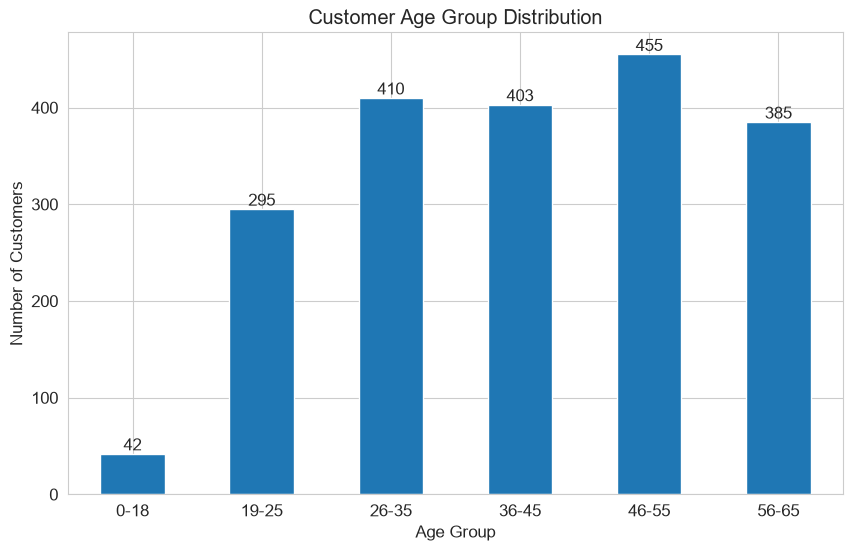

In [52]:
# Create Age Groups
df["age_group"] = pd.cut(
    df["age"],
    bins=[0, 18, 25, 35, 45, 55, 65],
    labels=["0-18", "19-25", "26-35", "36-45", "46-55", "56-65"]
)

# Age Group Distribution

age_counts = df["age_group"].value_counts().sort_index()

ax = age_counts.plot(kind="bar")

plt.title("Customer Age Group Distribution")
plt.xlabel("Age Group")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)

for x, y in enumerate(age_counts):
    ax.text(x, y, str(y), ha="center", va="bottom")

plt.show()

Observation : The business can focus its marketing campaigns and product offers on the 46–55 age group to target its largest customer segment.

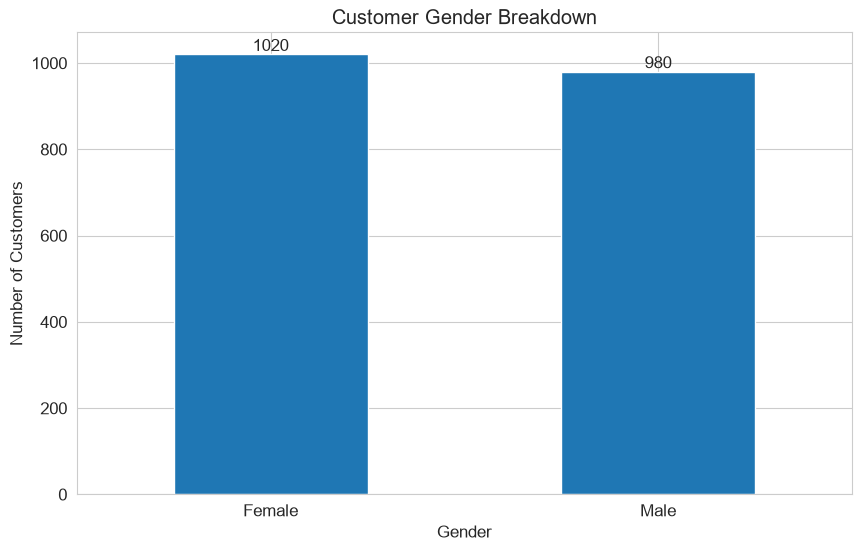

In [48]:
# Count customers by gender
gender_counts = df["gender"].value_counts()

# Plot gender breakdown
ax = gender_counts.plot(kind="bar")

plt.title("Customer Gender Breakdown")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)

for x, y in enumerate(gender_counts):
    ax.text(x, y, str(y), ha="center", va="bottom")

plt.show()

Observation : The business can therefore target both male and female customers rather than focusing heavily on one gender.

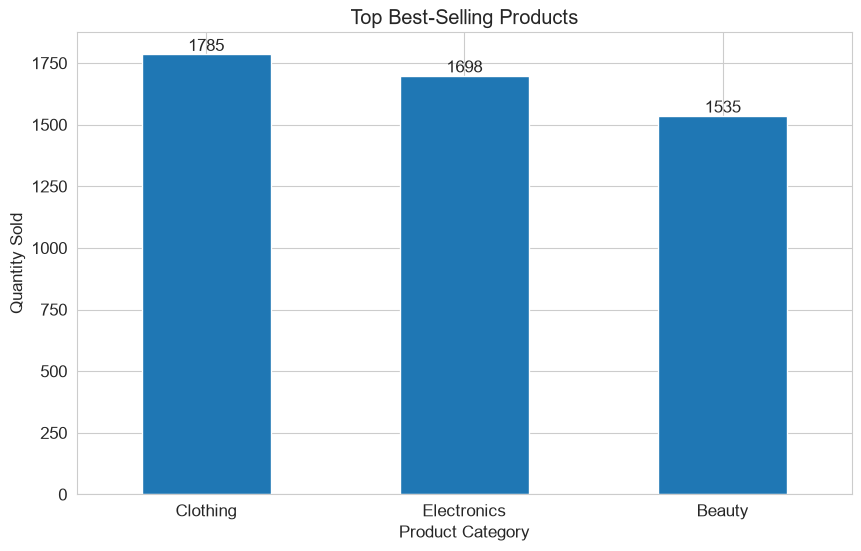

In [31]:
# Top-selling categories
top_prod = df.groupby("category")["quantiy"].sum().sort_values(ascending=False).head(10)

top_prod.plot(kind="bar")

plt.title("Top Best-Selling Products")
plt.xlabel("Product Category")
plt.ylabel("Quantity Sold")
plt.xticks(rotation=0)

for x, y in enumerate(top_10):
    plt.text(x, y, str(int(y)), ha="center", va="bottom")
    
plt.show()

Observation : Clothing has the highest quantity sold among the product categories. The retail business can prioritize clothing inventory and promotions to meet customer demand.

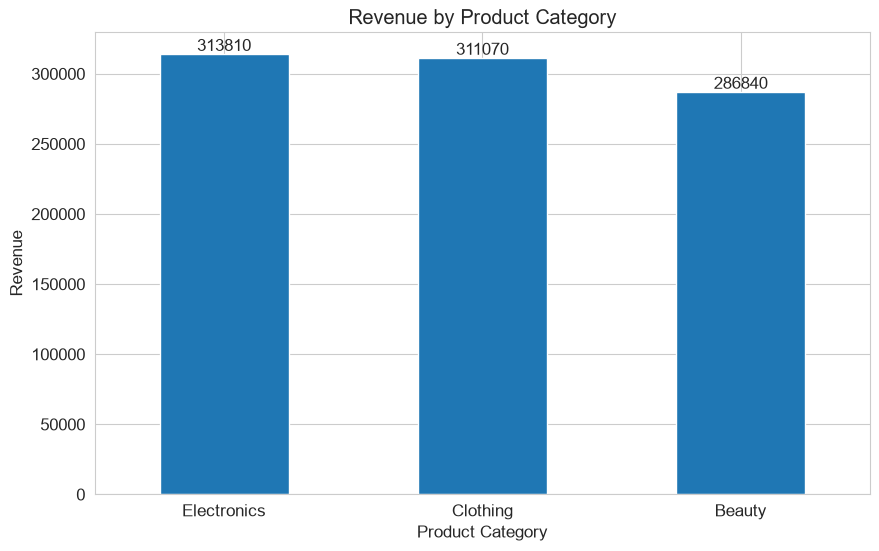

In [53]:
# Revenue by Product Category
revenue = df.groupby("category")["total_sale"].sum().sort_values(ascending=False)

ax = revenue.plot(kind="bar")

plt.title("Revenue by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Revenue")
plt.xticks(rotation=0)

for x, y in enumerate(revenue):
    ax.text(x, y, str(int(y)), ha="center", va="bottom")

plt.show()

Obseravtion : The business can focus on Electronics and Clothing while also improving sales of Beauty products.

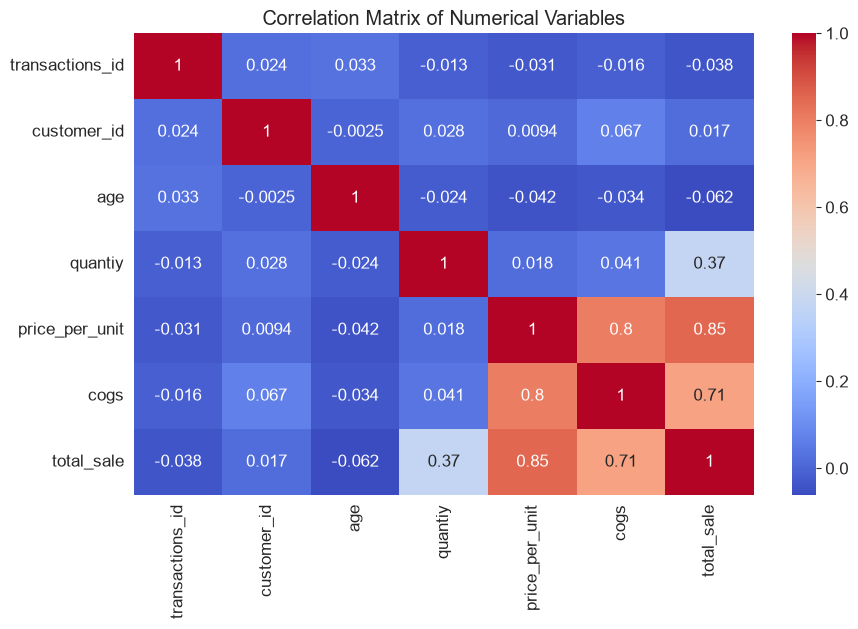

In [37]:
# Correlation Heatmap
correlation = df.select_dtypes(include="number").corr()

sns.heatmap(correlation, annot=True, cmap="coolwarm")

plt.title("Correlation Matrix of Numerical Variables")
plt.show()

Obseravtion : Total sales are strongly related to price per unit. COGS also has a strong relationship with total sales, while quantity has a moderate relationship.

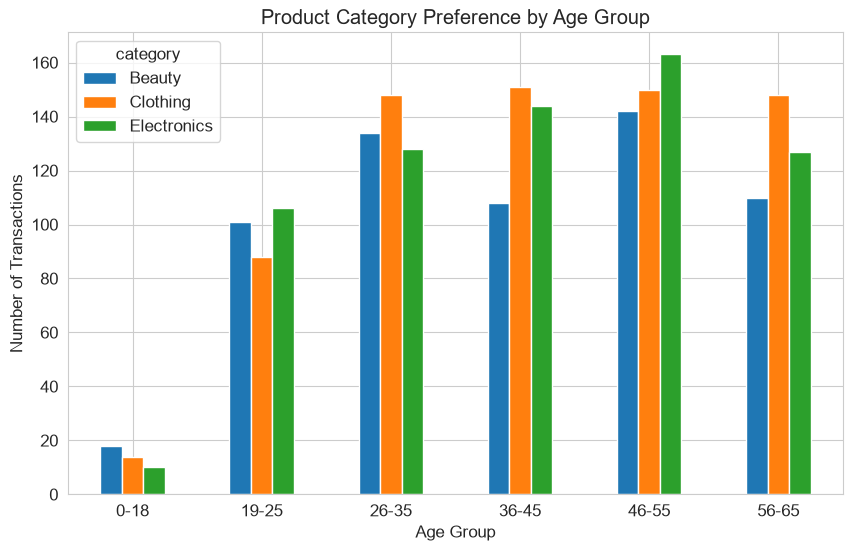

In [38]:
# Additional Visualization: Age Group and Product Category
age_category = pd.crosstab(df["age_group"], df["category"])

age_category.plot(kind="bar")

plt.title("Product Category Preference by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=0)
plt.show()

Observation : The 46–55 age group shows the highest number of transactions, especially for Electronics. Clothing is popular across most age groups, while the 0–18 age group has the fewest transactions.

~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
                                                -- CONCLUSION --
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
                                                                      
the following actions can help improve business performance:
    
1.Focus on Electronics and Clothing: These categories generate the highest revenue,
   so the business should maintain enough stock and run promotions for these products.
       
2.Target the 46–55 age group: This is the largest customer group.
  The business can create targeted offers and marketing campaigns for this age group.
    
3.Prepare for seasonal demand: Sales increase toward the end of the year and decline in January. 
  The business should increase inventory and promotions before the high-sales period and plan offers for January to improve sales.
      
4.Improve Beauty category sales: Beauty has the lowest revenue among the three categories. 
  The business can use discounts, bundles, and targeted promotions to increase Beauty sales.

~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~